In [ ]:
!pip install anthropic

In [ ]:
# @title Step 1: Imports and Configuration
import os
import ast
import json
import time
import torch
import pandas as pd
import anthropic
from tqdm.notebook import tqdm  # Use the notebook-friendly version of tqdm
from datasets import load_dataset
from transformers import pipeline
from google.colab import userdata, files

# --- Configuration ---
CONFIG = {
    "DATASET_NAME": "politifact",
    "DATASET_SPLIT": "train",
    "VERIFIER_MODEL_NAME": "cross-encoder/nli-deberta-v3-small",
    "DECOMPOSITION_CACHE_PATH": "decomposition_cache.json",
    "OUTPUT_FILE_PATH": "politifact_minicheck_results.jsonl",
    "RATE_LIMIT_DELAY_SECONDS": 2,
    "CACHE_SAVE_INTERVAL": 25,
    "MAX_RECORDS": 150,  # Set to a number for testing, or None to run all
}

# Access the API key from Colab Secrets
try:
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    print("Anthropic API Key loaded successfully.")
except userdata.SecretNotFoundError:
    print("ERROR: ANTHROPIC_API_KEY not found. Please add it to Colab Secrets (key icon on the left).")
    ANTHROPIC_API_KEY = None

✅ Anthropic API Key loaded successfully.


In [ ]:
# @title Step 2: Helper Functions for Loading Model and Decomposing Claims
def load_json_cache(path: str) -> dict:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}

def save_json_cache(path: str, cache_data: dict):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(cache_data, f, indent=2)

def load_processed_ids(output_path: str) -> set:
    processed_ids = set()
    if os.path.exists(output_path):
        with open(output_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    record_id = json.loads(line).get("claim")
                    if record_id: processed_ids.add(record_id)
                except json.JSONDecodeError:
                    continue
    return processed_ids

def get_anthropic_client():
    if not ANTHROPIC_API_KEY:
        raise ValueError("Anthropic API Key is not available.")
    return anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

def decompose_claim_with_claude(client: anthropic.Anthropic, claim: str) -> list[str]:
    try:
        message = client.messages.create(
            model="claude-3-5-sonnet-20240620",
            max_tokens=512,
            system="You are a linguistic expert. Break the statement into a Python list of simple, verifiable sub-claims. Return only the list.",
            messages=[{"role": "user", "content": f"Statement: \"{claim}\""}]
        )
        return ast.literal_eval(message.content[0].text)
    except Exception:
        return [claim]

def load_verifier_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading verifier model on device: {device}")
    return pipeline("text-classification", model=CONFIG["VERIFIER_MODEL_NAME"], device=device)

def verify_sub_claims_batch(verifier, sub_claims: list[str], article: str) -> list[str]:
    if not sub_claims: return []
    pairs = [(article, sub) for sub in sub_claims]
    results = verifier(pairs, batch_size=len(pairs), top_k=1) # top_k=1 is efficient
    label_map = {"ENTAILMENT": "Supported", "CONTRADICTION": "Contradicted", "NEUTRAL": "Not Enough Information"}
    return [label_map.get(res[0]['label'], "Not Enough Information") for res in results]

def process_record(record: dict, claude_client, verifier, decomp_cache: dict) -> dict:
    claim = record.get("claim", "")
    article = record.get("evidence", "")
    if claim in decomp_cache:
        sub_claims = decomp_cache[claim]
    else:
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
        sub_claims = decompose_claim_with_claude(claude_client, claim)
        decomp_cache[claim] = sub_claims
    verdicts = verify_sub_claims_batch(verifier, sub_claims, article)
    final_verdict = "False" if "Contradicted" in verdicts else "True"
    return {
        "claim": claim,
        "original_label": record.get("label"),
        "minicheck_verdict": final_verdict,
        "minicheck_details": [{"sub_claim": s, "verdict": v} for s, v in zip(sub_claims, verdicts)]
    }

print("Helper functions defined successfully.")

✅ Helper functions defined successfully.


In [ ]:
# @title Step 4: Run the Minicheck Process
def main():
    print("--- Starting Scalable MiniCheck on Politifact ---")
    if not ANTHROPIC_API_KEY:
      print(" Main process cannot start. API Key is missing.")
      return

    claude_client = get_anthropic_client()
    verifier_pipeline = load_verifier_model()
    dataset = pd.read_csv("train_data.csv")
    decomposition_cache = load_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"])
    processed_claims = load_processed_ids(CONFIG["OUTPUT_FILE_PATH"])

    print(f"Found {len(decomposition_cache)} cached decompositions.")
    print(f"Found {len(processed_claims)} already processed records to skip.")

    records_to_process = dataset.select(range(CONFIG["MAX_RECORDS"])) if CONFIG["MAX_RECORDS"] else dataset

    with open(CONFIG["OUTPUT_FILE_PATH"], 'a', encoding='utf-8') as f_out:
        for i, record in enumerate(tqdm(records_to_process, desc="Processing Politifact")):
            claim = record.get("claim")
            if not claim or claim in processed_claims:
                continue
            try:
                result = process_record(record, claude_client, verifier_pipeline, decomposition_cache)
                f_out.write(json.dumps(result) + '\n')
            except Exception as e:
                print(f"\n[ERROR] Failed on record {i}: {claim}. Error: {e}")
            if (i + 1) % CONFIG["CACHE_SAVE_INTERVAL"] == 0:
                save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)

    save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    print("\n--- Processing Complete ---")
    print(f"Results saved to: {CONFIG['OUTPUT_FILE_PATH']}")

main()

--- 🚀 Starting Scalable MiniCheck on Politifact ---
Loading verifier model on device: cpu


Device set to use cpu


Found 0 cached decompositions.
Found 0 already processed records to skip.


AttributeError: 'DataFrame' object has no attribute 'select'

In [ ]:
# @title Step 5: View and Analyze Results
try:
    results_df = pd.read_json(CONFIG['OUTPUT_FILE_PATH'], lines=True)
    # Display the DataFrame with relevant columns
    display(results_df[['claim', 'original_label', 'minicheck_verdict', 'minicheck_details']].head())
except FileNotFoundError:
    print("Output file not found. Please run Step 4 first.")
except ValueError:
    print("Output file is empty or corrupted.")

--- 2. Configuring File Paths and Loading Secrets ---
✅ Anthropic API Key loaded successfully.
----------------------------------------

--- 3. Starting Main Data Processing ---
✅ Loaded 16921 training records and 2115 verification records.
🚨 ERROR: A required column was not found in a CSV: "['article_text'] not in index". Please check the column names in the CONFIG.
--- 4. Starting Evaluation of Results ---
Evaluating on 84 records with non-ambiguous labels.

📊 Overall Accuracy: 47.62%

📋 Classification Report:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        44
        True       0.48      1.00      0.65        40

    accuracy                           0.48        84
   macro avg       0.24      0.50      0.32        84
weighted avg       0.23      0.48      0.31        84



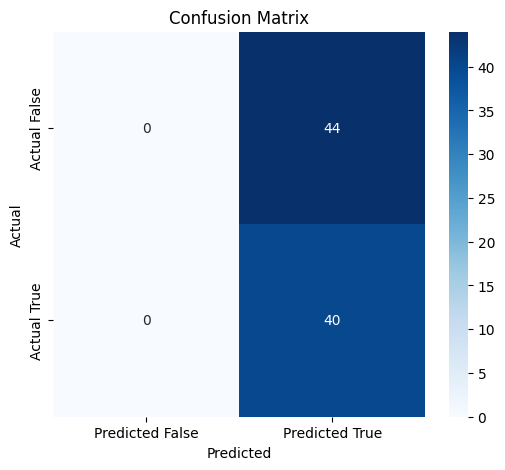


🔍 Found 44 incorrect predictions to analyze.


,claim,original_label,minicheck_verdict,minicheck_details
0,"The Obama administration ""was successful in rushing a massive spending bill through Congress in just two days — after which it sat on the presiden...",false,True,"[{'sub_claim': 'The Obama administration ""was successful in rushing a massive spending bill through Congress in just two days — after which it sat..."
4,"Says, ""Yet in Salem they have traditionally waited until the money is almost gone to pay for the most important things in our state’s budget.""",false,True,"[{'sub_claim': 'Says, ""Yet in Salem they have traditionally waited until the money is almost gone to pay for the most important things in our stat..."
9,"State budget cuts for local schools resulted in ""nearly 4,000 educator layoffs""",false,True,"[{'sub_claim': 'State budget cuts for local schools resulted in ""nearly 4,000 educator layoffs""', 'verdict': 'Not Enough Information'}]"
16,"Says Donald Trump got ""exposed for raping a 13-year-old"" in retaliation for law enforcement officers ""killing black people.""",false,True,"[{'sub_claim': 'Says Donald Trump got ""exposed for raping a 13-year-old"" in retaliation for law enforcement officers ""killing black people.""', 've..."
19,"""Black homeownership just hit the highest level it has ever been in the history of our country.""",false,True,"[{'sub_claim': '""Black homeownership just hit the highest level it has ever been in the history of our country.""', 'verdict': 'Not Enough Informat..."


In [ ]:
# @title MiniCheck End-to-End Workflow (Adapted for CSV file)

import os
import ast
import json
import time
import torch
import pandas as pd
import anthropic
from tqdm.notebook import tqdm
from transformers import pipeline
from google.colab import userdata
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import io

# --- 3. CONFIGURATION AND API KEY ---
print("--- 2. Configuring File Paths and Loading Secrets ---")
CONFIG = {
    # Paths to your pre-uploaded files
    "TRAIN_CSV_PATH": "/content/train_data.csv",
    "VERIFICATION_CSV_PATH": "/content/validation_data.csv",
    # Column names in your files. Adjust if necessary.
    "CLAIM_COLUMN": "statement",
    "LABEL_COLUMN": "verdict",
    "EVIDENCE_COLUMN": "article_text", # The column in your verification file with the full text
    "COMMON_COLUMN": "statement",      # The column to merge the two files on

    # Model and process settings
    "VERIFIER_MODEL_NAME": "cross-encoder/nli-deberta-v3-small",
    "DECOMPOSITION_CACHE_PATH": "decomposition_cache.json",
    "OUTPUT_FILE_PATH": "politifact_minicheck_results.jsonl",
    "RATE_LIMIT_DELAY_SECONDS": 2,
    "CACHE_SAVE_INTERVAL": 25,
    "MAX_RECORDS": None, # Set to None to run on the entire dataset
}


try:
    ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    print(" Anthropic API Key loaded successfully.")
except userdata.SecretNotFoundError:
    print(" ERROR: ANTHROPIC_API_KEY not found in Colab Secrets.")
    ANTHROPIC_API_KEY = None
print("-" * 40 + "\n")


# --- 4. HELPER AND PROCESSING FUNCTIONS ---
def load_json_cache(path: str) -> dict:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f: return json.load(f)
    return {}

def save_json_cache(path: str, cache_data: dict):
    with open(path, 'w', encoding='utf-8') as f: json.dump(cache_data, f, indent=2)

def load_processed_ids(output_path: str) -> set:
    processed_ids = set()
    if os.path.exists(output_path):
        with open(output_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    record_id = json.loads(line).get("claim")
                    if record_id: processed_ids.add(record_id)
                except json.JSONDecodeError: continue
    return processed_ids

def get_anthropic_client():
    if not ANTHROPIC_API_KEY: raise ValueError("Anthropic API Key is not available.")
    return anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

def decompose_claim_with_claude(client: anthropic.Anthropic, claim: str) -> list[str]:
    try:
        message = client.messages.create(
            model="claude-3-5-sonnet-20240620", max_tokens=512,
            system="You are a linguistic expert. Break the statement into a Python list of simple, verifiable sub-claims. Return only the list.",
            messages=[{"role": "user", "content": f"Statement: \"{claim}\""}]
        )
        return ast.literal_eval(message.content[0].text)
    except Exception: return [claim]

def load_verifier_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading verifier model on device: {device}")
    return pipeline("text-classification", model=CONFIG["VERIFIER_MODEL_NAME"], device=device)

def verify_sub_claims_batch(verifier, sub_claims: list[str], article: str) -> list[str]:
    if not sub_claims or not article or pd.isna(article):
        return ["Not Enough Information"] * len(sub_claims)
    pairs = [(str(article), sub) for sub in sub_claims]
    results = verifier(pairs, batch_size=len(pairs), top_k=1)
    label_map = {"ENTAILMENT": "Supported", "CONTRADICTION": "Contradicted", "NEUTRAL": "Not Enough Information"}
    return [label_map.get(res[0]['label'], "Not Enough Information") for res in results]

def process_record(record: dict, claude_client, verifier, decomp_cache: dict) -> dict:
    claim = record.get(CONFIG["CLAIM_COLUMN"], "")
    label = record.get(CONFIG["LABEL_COLUMN"], "")
    evidence = record.get(CONFIG["EVIDENCE_COLUMN"], "")

    if claim in decomp_cache:
        sub_claims = decomp_cache[claim]
    else:
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
        sub_claims = decompose_claim_with_claude(claude_client, claim)
        decomp_cache[claim] = sub_claims
    verdicts = verify_sub_claims_batch(verifier, sub_claims, evidence)
    final_verdict = "False" if "Contradicted" in verdicts else "True"
    return {
        "claim": claim, "original_label": label,
        "minicheck_verdict": final_verdict,
        "minicheck_details": [{"sub_claim": s, "verdict": v} for s, v in zip(sub_claims, verdicts)]
    }

# --- 5. MAIN EXECUTION FUNCTION ---
def run_main_processing():
    print("--- 3. Starting Main Data Processing ---")
    if not all([ANTHROPIC_API_KEY, CONFIG["TRAIN_CSV_PATH"], CONFIG["VERIFICATION_CSV_PATH"]]):
        print(" Main process cannot start. API Key or a CSV file path is missing.")
        return

    try:
        train_df = pd.read_csv(CONFIG["TRAIN_CSV_PATH"])
        verification_df = pd.read_csv(CONFIG["VERIFICATION_CSV_PATH"])
        print(f" Loaded {len(train_df)} training records and {len(verification_df)} verification records.")

        merged_df = pd.merge(
            train_df,
            verification_df[[CONFIG["COMMON_COLUMN"], CONFIG["EVIDENCE_COLUMN"]]],
            on=CONFIG["COMMON_COLUMN"],
            how="left"
        )
        print(f" Successfully merged dataframes. Resulting data has {len(merged_df)} records.")
        # Check for claims that didn't find a match in the verification data
        unmatched_claims = merged_df[merged_df[CONFIG["EVIDENCE_COLUMN"]].isnull()].shape[0]
        if unmatched_claims > 0:
            print(f"⚠️ Warning: {unmatched_claims} claims did not have matching evidence and will be skipped or result in 'Not Enough Information'.")


    except FileNotFoundError as e:
        print(f" ERROR: A CSV file was not found: {e}. Please ensure the paths in the CONFIG are correct.")
        return
    except KeyError as e:
        print(f" ERROR: A required column was not found in a CSV: {e}. Please check the column names in the CONFIG.")
        return

    claude_client, verifier_pipeline = get_anthropic_client(), load_verifier_model()
    decomposition_cache = load_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"])
    processed_claims = load_processed_ids(CONFIG["OUTPUT_FILE_PATH"])
    print(f"Found {len(decomposition_cache)} cached decompositions and {len(processed_claims)} processed records to skip.")

    records_to_process = merged_df.head(CONFIG["MAX_RECORDS"]) if CONFIG["MAX_RECORDS"] else merged_df
    with open(CONFIG["OUTPUT_FILE_PATH"], 'a', encoding='utf-8') as f_out:
        for index, record in tqdm(records_to_process.iterrows(), total=len(records_to_process), desc="Processing Politifact"):
            claim = record.get(CONFIG["CLAIM_COLUMN"])
            if not claim or claim in processed_claims: continue
            try:
                result = process_record(record, claude_client, verifier_pipeline, decomposition_cache)
                f_out.write(json.dumps(result) + '\n')
            except Exception as e:
                print(f"\n[ERROR] Failed on record {index}: {claim}. Error: {e}")
            if (index + 1) % CONFIG["CACHE_SAVE_INTERVAL"] == 0:
                save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    print("\n---  Processing Complete ---")
    print(f"Results saved to: {CONFIG['OUTPUT_FILE_PATH']}\n")

# --- 6. EVALUATION FUNCTION ---
def run_evaluation():
    print("--- 4. Starting Evaluation of Results ---")
    try:
        df = pd.read_json(CONFIG['OUTPUT_FILE_PATH'], lines=True)
        if df.empty:
            print("Results file is empty. Nothing to evaluate.")
            return
    except FileNotFoundError:
        print(" Results file not found. Cannot run evaluation.")
        return

    def map_to_binary(label):
        if label in ['true', 'mostly-true']: return True
        if label in ['false', 'pants-on-fire']: return False
        return pd.NA
    df['ground_truth_binary'] = df['original_label'].apply(map_to_binary)
    df['minicheck_verdict_bool'] = df['minicheck_verdict'].apply(lambda x: x == 'True')
    eval_df = df.dropna(subset=['ground_truth_binary']).copy()
    eval_df['ground_truth_binary'] = eval_df['ground_truth_binary'].astype(bool)

    print(f"Evaluating on {len(eval_df)} records with non-ambiguous labels.")
    if eval_df.empty:
        print("No records with evaluatable labels found.")
        return

    y_true, y_pred = eval_df['ground_truth_binary'], eval_df['minicheck_verdict_bool']
    print(f"\n Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print(" Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['False', 'True'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted False', 'Predicted True'], yticklabels=['Actual False', 'Actual True'])
    plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()
    incorrect_predictions = eval_df[eval_df['ground_truth_binary'] != eval_df['minicheck_verdict_bool']]
    print(f"\n Found {len(incorrect_predictions)} incorrect predictions to analyze.")
    pd.set_option('display.max_colwidth', 150)
    display(incorrect_predictions[['claim', 'original_label', 'minicheck_verdict', 'minicheck_details']].head())

# --- RUN EVERYTHING ---
if __name__ == "__main__":
    run_main_processing()
    run_evaluation()

In [ ]:
# @title Data Enrichment Workflow using OpenAI

# --- 2. IMPORTS ---
import os
import pandas as pd
import openai
from tqdm.notebook import tqdm
from google.colab import userdata, files
import io
import time

# --- 3. UPLOAD YOUR CSV DATA ---
# --- 4. CONFIGURATION AND API KEY ---
print("--- 3. Configuring and Loading Secrets ---")
CONFIG = {
    "INPUT_CSV_PATH": "/content/train_data.csv",
    "OUTPUT_CSV_PATH": "train_data_augmented_openai.csv",
    # Column names in your CSV. Adjust if necessary.
    "CLAIM_COLUMN": "statement",
    "LABEL_COLUMN": "verdict",
    "RATE_LIMIT_DELAY_SECONDS": 1, # OpenAI's default rate limits are often higher
    "MAX_RECORDS": 150, # Set to None to run on the entire file
}

try:
    # Get the API key from Colab's secret manager
    OPENAI_API_KEY = userdata.get('OPEN_API_KEY')
    print(" OpenAI API Key loaded successfully.")
    # Set the key for the openai library to use
    openai.api_key = OPENAI_API_KEY
except userdata.SecretNotFoundError:
    print(" ERROR: OPENAI_API_KEY not found in Colab Secrets. Please add it to run.")
    OPENAI_API_KEY = None
print("-" * 40 + "\n")


# --- 5. EXPLANATION GENERATION FUNCTION (for OpenAI) ---
def generate_explanation(client: openai.OpenAI, claim: str, verdict: str) -> str:
    """
    Asks OpenAI's GPT-3.5 Turbo to generate a plausible explanation.
    """
    system_prompt = "You are a neutral, impartial fact-checker. Given a statement and its final verdict, please provide a brief, logical, and plausible explanation for why that verdict was reached."
    user_prompt = f"Statement: \"{claim}\"\nVerdict: {verdict}\n\nExplanation:"

    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            max_tokens=150,
            temperature=0.5,
        )
        explanation = response.choices[0].message.content.strip()
        return explanation
    except Exception as e:
        print(f"  [Error] API call failed: {e}")
        return "Could not generate explanation."

# --- 6. MAIN AUGMENTATION PROCESS ---
def run_augmentation():
    print("--- 4. Starting Data Augmentation Process ---")
    if not OPENAI_API_KEY or not CONFIG["INPUT_CSV_PATH"]:
        print(" Main process cannot start. API Key or CSV file is missing.")
        return

    try:
        df = pd.read_csv(CONFIG["INPUT_CSV_PATH"])
        print(f" Loaded {len(df)} records from {CONFIG['INPUT_CSV_PATH']}")
    except FileNotFoundError:
        print(f" ERROR: Input CSV file not found.")
        return

    # Initialize the OpenAI client
    client = openai.OpenAI(api_key=OPENAI_API_KEY)

    # Limit records for testing if needed
    records_to_process = df.head(CONFIG["MAX_RECORDS"]) if CONFIG["MAX_RECORDS"] else df

    explanations = []

    for index, row in tqdm(records_to_process.iterrows(), total=len(records_to_process), desc="Generating Explanations"):
        claim = row.get(CONFIG["CLAIM_COLUMN"])
        verdict = row.get(CONFIG["LABEL_COLUMN"])

        if pd.isna(claim) or pd.isna(verdict):
            explanations.append("Invalid input data.")
            continue

        # Call the function to get the explanation from OpenAI
        explanation = generate_explanation(client, claim, verdict)
        explanations.append(explanation)
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])

    # Add the new 'explanation' column to the DataFrame
    records_to_process['explanation'] = explanations

    # Save the new, augmented CSV file
    records_to_process.to_csv(CONFIG["OUTPUT_CSV_PATH"], index=False)

    print("\n---  Augmentation Complete ---")
    print(f"New file saved as: {CONFIG['OUTPUT_CSV_PATH']}\n")

    # Display the first few rows of the new file
    print(" Preview of Augmented Data:")
    display(records_to_process[['statement', 'verdict', 'explanation']].head())

# --- 7. DOWNLOAD THE AUGMENTED FILE ---
def download_augmented_file():
    try:
        print("\n--- 5. Downloading Augmented File ---")
        files.download(CONFIG["OUTPUT_CSV_PATH"])
    except NameError:
        print(f" Could not find the output file because the script did not run successfully.")
    except FileNotFoundError:
        print(f" Could not find the output file '{CONFIG['OUTPUT_CSV_PATH']}'. Please run the augmentation step first.")

# --- RUN EVERYTHING ---
if __name__ == "__main__":
      run_augmentation()
      download_augmented_file()

--- 3. Configuring and Loading Secrets ---
✅ OpenAI API Key loaded successfully.
----------------------------------------

--- 4. Starting Data Augmentation Process ---
✅ Loaded 16921 records from /content/train_data.csv


Generating Explanations:   0%|          | 0/150 [00:00<?, ?it/s]


--- ✅ Augmentation Complete ---
New file saved as: train_data_augmented_openai.csv

📋 Preview of Augmented Data:


/tmp/ipython-input-23-1068055287.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  records_to_process['explanation'] = explanations


,statement,verdict,explanation
0,"The Obama administration ""was successful in rushing a massive spending bill through Congress in just two days — after which it sat on the presiden...",false,"The statement is false. In reality, the process of passing a spending bill through Congress is much more complex and time-consuming than suggested..."
1,"""The top man at Yale Law School came out ... with just a raging report"" about former HP CEO Carly Fiorina, saying she is ""one of the worst executi...",mostly-true,The statement is mostly true because it accurately conveys the essence of the reported comments made by the top man at Yale Law School about Carly...
2,"""And while (Ted) Strickland proposed cuts for services for children, he wasted over $250,000 remodeling his bathrooms at the governor’s mansion.""",pants-fire,"The statement is rated as ""pants-fire"" because it is a blatant falsehood. There is no credible evidence to support the claim that Ted Strickland p..."
3,"Says Donald Trump tweeted, ""I ordered the Treasury secretary to send checks to Americans! First however, we will go through your social media hist...",pants-fire,"This statement is false and has been rated as ""pants-fire."" There is no credible evidence or record of Donald Trump making such a tweet. The conte..."
4,"Says, ""Yet in Salem they have traditionally waited until the money is almost gone to pay for the most important things in our state’s budget.""",false,The statement is false because it makes a generalization that may not be accurate. While it is possible that there have been instances where fundi...



--- 5. Downloading Augmented File ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- 2. Configuring and Loading Secrets ---
✅ OpenAI API Key loaded successfully.
----------------------------------------

--- 3. Starting Main MiniCheck Processing ---
✅ Loaded 150 records from '/content/train_data_augmented_openai.csv'.
Found 149 cached decompositions and 1 processed records to skip.


Running MiniCheck:   0%|          | 0/150 [00:00<?, ?it/s]


--- ✅ Processing Complete ---
Results saved to: minicheck_run_results_v2.jsonl

--- 4. Starting Evaluation of Results ---
Evaluating on 110 records with non-ambiguous labels.

📊 Overall Accuracy: 82.73%

📋 Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.73      0.84        70
        True       0.68      1.00      0.81        40

    accuracy                           0.83       110
   macro avg       0.84      0.86      0.83       110
weighted avg       0.88      0.83      0.83       110



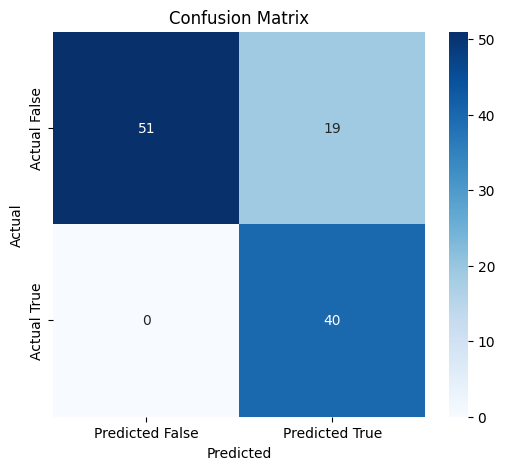


🔍 Found 19 incorrect predictions to analyze.


,claim,original_label,minicheck_verdict,minicheck_details
6,"""Malia Obama expelled from Harvard.""",pants-fire,True,"[{'sub_claim': '""Malia Obama expelled from Harvard.""', 'verdict': 'Supported'}]"
25,President Joe Biden gave Congress an exemption from vaccine mandate,false,True,"[{'sub_claim': 'President Joe Biden gave Congress an exemption from vaccine mandate', 'verdict': 'Supported'}]"
28,National Guard members turned their backs on Biden’s motorcade on Inauguration Day.,false,True,"[{'sub_claim': 'National Guard members turned their backs on Biden’s motorcade on Inauguration Day.', 'verdict': 'Supported'}]"
32,"Says President Barack Obama ""has not condemned"" shootings targeting police.",pants-fire,True,"[{'sub_claim': 'Says President Barack Obama ""has not condemned"" shootings targeting police.', 'verdict': 'Supported'}]"
36,"""Democrats and their allies (...) are manufacturing voters.""",pants-fire,True,"[{'sub_claim': '""Democrats and their allies (...) are manufacturing voters.""', 'verdict': 'Supported'}]"


In [ ]:
# @title Run MiniCheck with LLM-Based Verification (Bias Corrected)

# --- 1. IMPORTS ---
import os
import ast
import json
import time
import pandas as pd
import openai
from tqdm.notebook import tqdm
from google.colab import userdata, files
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 2. UPLOAD YOUR AUGMENTED CSV DATA ---


# --- 3. CONFIGURATION AND API KEY ---
print("--- 2. Configuring and Loading Secrets ---")
CONFIG = {
    "INPUT_CSV_PATH": "/content/train_data_augmented_openai.csv",
    "CLAIM_COLUMN": "statement",
    "LABEL_COLUMN": "verdict",
    "EVIDENCE_COLUMN": "explanation",
    "DECOMPOSER_MODEL": "gpt-3.5-turbo",
    "VERIFIER_MODEL": "gpt-3.5-turbo", # <-- CHANGED: Using an LLM as the verifier
    "DECOMPOSITION_CACHE_PATH": "minicheck_decomposition_cache.json",
    "OUTPUT_FILE_PATH": "minicheck_run_results_v2.jsonl", # New output file
    "RATE_LIMIT_DELAY_SECONDS": 1,
    "MAX_RECORDS": 200,
    "CACHE_SAVE_INTERVAL": 25,
}

try:
    OPENAI_API_KEY = userdata.get('OPEN_API_KEY')
    print(" OpenAI API Key loaded successfully.")
    openai.api_key = OPENAI_API_KEY
except userdata.SecretNotFoundError:
    print(" ERROR: OPENAI_API_KEY not found in Colab Secrets.")
    OPENAI_API_KEY = None
print("-" * 40 + "\n")


# --- 4. HELPER AND PROCESSING FUNCTIONS ---
def load_json_cache(path: str) -> dict:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f: return json.load(f)
    return {}

def save_json_cache(path: str, cache_data: dict):
    with open(path, 'w', encoding='utf-8') as f: json.dump(cache_data, f, indent=2)

def load_processed_ids(output_path: str) -> set:
    processed_ids = set()
    if os.path.exists(output_path):
        with open(output_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    record_id = json.loads(line).get("claim")
                    if record_id: processed_ids.add(record_id)
                except json.JSONDecodeError: continue
    return processed_ids

def decompose_claim_with_openai(client: openai.OpenAI, claim: str) -> list[str]:
    system_prompt = "You are a linguistic expert. Break the statement into a Python list of simple, verifiable sub-claims. Return only the list."
    try:
        response = client.chat.completions.create(
            model=CONFIG["DECOMPOSER_MODEL"],
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Statement: \"{claim}\""}
            ],
            max_tokens=256, temperature=0.0
        )
        return ast.literal_eval(response.choices[0].message.content.strip())
    except Exception:
        return [claim]

# --- NEW VERIFICATION FUNCTION ---
def verify_sub_claims_with_llm(client: openai.OpenAI, sub_claims: list[str], evidence: str) -> list[str]:
    """
    Uses an LLM to verify a list of sub-claims against a piece of evidence.
    """
    if not sub_claims or not evidence or pd.isna(evidence):
        return ["Not Enough Information"] * len(sub_claims)

    results = []
    for sub_claim in sub_claims:
        system_prompt = "You are a fact-checking expert. Based *only* on the provided Evidence, classify the Sub-claim. Respond with only one word: 'Supported', 'Contradicted', or 'Not Enough Information'."
        user_prompt = f"Evidence: \"{evidence}\"\n\nSub-claim: \"{sub_claim}\""
        try:
            response = client.chat.completions.create(
                model=CONFIG["VERIFIER_MODEL"],
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                max_tokens=5,
                temperature=0.0,
            )
            verdict = response.choices[0].message.content.strip().replace('.', '')
            # Ensure the verdict is one of the allowed labels
            if verdict not in ['Supported', 'Contradicted', 'Not Enough Information']:
                verdict = "Not Enough Information"
            results.append(verdict)
        except Exception as e:
            print(f"  [Error] Verification API call failed: {e}")
            results.append("Not Enough Information")
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"]) # Rate limit between each sub-claim verification
    return results

def process_record(record: dict, client: openai.OpenAI, decomp_cache: dict) -> dict:
    claim = record.get(CONFIG["CLAIM_COLUMN"], "")
    label = record.get(CONFIG["LABEL_COLUMN"], "")
    evidence = record.get(CONFIG["EVIDENCE_COLUMN"], "")

    if claim in decomp_cache:
        sub_claims = decomp_cache[claim]
    else:
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
        sub_claims = decompose_claim_with_openai(client, claim)
        decomp_cache[claim] = sub_claims

    # Call the new verification function
    verdicts = verify_sub_claims_with_llm(client, sub_claims, evidence)

    final_verdict = "False" if "Contradicted" in verdicts else "True"
    return {
        "claim": claim, "original_label": label,
        "minicheck_verdict": final_verdict,
        "minicheck_details": [{"sub_claim": s, "verdict": v} for s, v in zip(sub_claims, verdicts)]
    }

# --- 5. MAIN EXECUTION FUNCTION ---
def run_main_processing():
    print("--- 3. Starting Main MiniCheck Processing ---")
    if not all([OPENAI_API_KEY, CONFIG["INPUT_CSV_PATH"]]):
        print(" Main process cannot start. API Key or input CSV file is missing.")
        return

    try:
        df = pd.read_csv(CONFIG["INPUT_CSV_PATH"])
        print(f" Loaded {len(df)} records from '{CONFIG['INPUT_CSV_PATH']}'.")
    except FileNotFoundError:
        print(f" ERROR: Input CSV file not found.")
        return

    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    decomposition_cache = load_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"])
    processed_claims = load_processed_ids(CONFIG["OUTPUT_FILE_PATH"])
    print(f"Found {len(decomposition_cache)} cached decompositions and {len(processed_claims)} processed records to skip.")

    records_to_process = df.head(CONFIG["MAX_RECORDS"]) if CONFIG["MAX_RECORDS"] else df
    with open(CONFIG["OUTPUT_FILE_PATH"], 'a', encoding='utf-8') as f_out:
        for index, record in tqdm(records_to_process.iterrows(), total=len(records_to_process), desc="Running MiniCheck"):
            claim = record.get(CONFIG["CLAIM_COLUMN"])
            if not claim or claim in processed_claims: continue
            try:
                result = process_record(record, client, decomposition_cache)
                f_out.write(json.dumps(result) + '\n')
            except Exception as e:
                print(f"\n[ERROR] Failed on record {index}: {claim}. Error: {e}")
            if (index + 1) % CONFIG["CACHE_SAVE_INTERVAL"] == 0:
                save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    print("\n---  Processing Complete ---")
    print(f"Results saved to: {CONFIG['OUTPUT_FILE_PATH']}\n")

# --- 6. EVALUATION FUNCTION ---
def run_evaluation():
    print("--- 4. Starting Evaluation of Results ---")
    try:
        df = pd.read_json(CONFIG['OUTPUT_FILE_PATH'], lines=True)
        if df.empty:
            print("Results file is empty. Nothing to evaluate.")
            return
    except FileNotFoundError:
        print(" Results file not found. Cannot run evaluation.")
        return

    def map_to_binary(label):
        if label in ['true', 'mostly-true']: return True
        if label in ['false', 'pants-fire']: return False
        return pd.NA
    df['ground_truth_binary'] = df['original_label'].apply(map_to_binary)
    df['minicheck_verdict_bool'] = df['minicheck_verdict'].apply(lambda x: x == 'True')
    eval_df = df.dropna(subset=['ground_truth_binary']).copy()
    eval_df['ground_truth_binary'] = eval_df['ground_truth_binary'].astype(bool)

    print(f"Evaluating on {len(eval_df)} records with non-ambiguous labels.")
    if eval_df.empty:
        print("No records with evaluatable labels found.")
        return

    y_true, y_pred = eval_df['ground_truth_binary'], eval_df['minicheck_verdict_bool']
    print(f"\n Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print(" Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['False', 'True'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted False', 'Predicted True'], yticklabels=['Actual False', 'Actual True'])
    plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()
    incorrect_predictions = eval_df[eval_df['ground_truth_binary'] != eval_df['minicheck_verdict_bool']]
    print(f"\n Found {len(incorrect_predictions)} incorrect predictions to analyze.")
    pd.set_option('display.max_colwidth', 150)
    display(incorrect_predictions[['claim', 'original_label', 'minicheck_verdict', 'minicheck_details']].head())

# --- RUN EVERYTHING ---
if __name__ == "__main__":
    run_main_processing()
    run_evaluation()

--- 2. Configuring and Loading Secrets ---
✅ Together AI API Key loaded successfully.
----------------------------------------

✅ Together AI API Key loaded successfully.
----------------------------------------

--- 3. Starting Main MiniCheck Processing ---
✅ Loaded 10269 records from '/content/train2.jsonl'.
Found 0 cached decompositions and 0 processed records to skip.


Running MiniCheck:   0%|          | 0/200 [00:00<?, ?it/s]


--- ✅ Processing Complete ---
Results saved to: mixtral_minicheck_results.jsonl

--- 4. Starting Evaluation of Results ---
Evaluating on 200 records with non-ambiguous labels.

📊 Overall Accuracy: 40.00%

📋 Classification Report:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       120
        True       0.40      1.00      0.57        80

    accuracy                           0.40       200
   macro avg       0.20      0.50      0.29       200
weighted avg       0.16      0.40      0.23       200



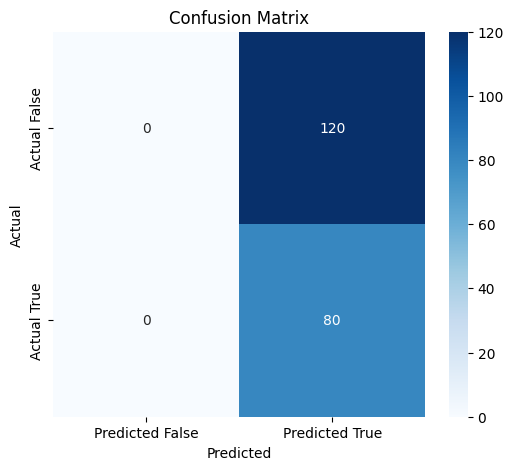


🔍 Found 120 incorrect predictions to analyze.


,claim,original_label,minicheck_verdict,minicheck_details
0,Says the Annies List political group supports third-trimester abortions on demand.,false,True,"[{'sub_claim': 'Says the Annies List political group supports third-trimester abortions on demand.', 'verdict': 'Not Enough Information', 'reasoni..."
1,When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.,half-true,True,[{'sub_claim': 'When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs admi...
3,Health care reform legislation is likely to mandate free sex change surgeries.,false,True,"[{'sub_claim': 'Health care reform legislation is likely to mandate free sex change surgeries.', 'verdict': 'Not Enough Information', 'reasoning':..."
4,The economic turnaround started at the end of my term.,half-true,True,"[{'sub_claim': 'The economic turnaround started at the end of my term.', 'verdict': 'Not Enough Information', 'reasoning': 'API call failed: Error..."
6,Jim Dunnam has not lived in the district he represents for years now.,barely-true,True,"[{'sub_claim': 'Jim Dunnam has not lived in the district he represents for years now.', 'verdict': 'Not Enough Information', 'reasoning': 'API cal..."


In [ ]:
# @title MiniCheck with Mistral (Decomposer & Verifier)

# --- 1. IMPORTS ---
import os
import ast
import json
import time
import re
import pandas as pd
import anthropic # <-- The only API library needed now
from tqdm.notebook import tqdm
from google.colab import userdata, files
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


# --- 3. CONFIGURATION AND API KEY ---
print("--- 2. Configuring and Loading Secrets ---")
CONFIG = {
    "INPUT_FILE_PATH": "/content/train2.jsonl",
    "CLAIM_COLUMN": "claim",
    "LABEL_COLUMN": "label",
    "EVIDENCE_COLUMN": "justification",
    # --- MODEL CONFIGURATION ---
    # --- MODIFIED: Using Mistral's Mixtral model for both tasks ---
    "DECOMPOSER_MODEL": "mistralai/Mixtral-8x22B-Instruct-v0.1",
    "VERIFIER_MODEL": "mistralai/Mixtral-8x22B-Instruct-v0.1",

    "DECOMPOSITION_CACHE_PATH": "mixtral_decomposition_cache.json", # New cache file
    "OUTPUT_FILE_PATH": "mixtral_minicheck_results.jsonl",      # New output file
    "RATE_LIMIT_DELAY_SECONDS": 1,
    "MAX_RECORDS": 200,
    "CACHE_SAVE_INTERVAL": 25,
}

try:
    # --- MODIFIED: Only need the Together AI key ---
    TOGETHER_AI_API_KEY = userdata.get('TOGETHER_AI_API_KEY')
    print(" Together AI API Key loaded successfully.")
except userdata.SecretNotFoundError:
    print(" ERROR: TOGETHER_AI_API_KEY not found in Colab Secrets.")
    TOGETHER_AI_API_KEY = None
print("-" * 40 + "\n")



try:
    # --- Only need the Together AI key ---
    TOGETHER_AI_API_KEY = userdata.get('TOGETHER_AI_API_KEY')
    print(" Together AI API Key loaded successfully.")
except userdata.SecretNotFoundError:
    print(" ERROR: TOGETHER_AI_API_KEY not found in Colab Secrets.")
    TOGETHER_AI_API_KEY = None
print("-" * 40 + "\n")


# --- 4. HELPER AND PROCESSING FUNCTIONS ---
def load_json_cache(path: str) -> dict:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f: return json.load(f)
    return {}

def save_json_cache(path: str, cache_data: dict):
    with open(path, 'w', encoding='utf-8') as f: json.dump(cache_data, f, indent=2)

def load_processed_ids(output_path: str) -> set:
    processed_ids = set()
    if os.path.exists(output_path):
        with open(output_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    record_id = json.loads(line).get("claim")
                    if record_id: processed_ids.add(record_id)
                except json.JSONDecodeError: continue
    return processed_ids

def decompose_claim(client: openai.OpenAI, claim: str) -> list[str]:
    system_prompt = "You are a linguistic expert. Break the statement into a Python list of simple, verifiable sub-claims. Return only the list."
    try:
        response = client.chat.completions.create(
            model=CONFIG["DECOMPOSER_MODEL"],
            messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": f"Statement: \"{claim}\""}],
            max_tokens=256, temperature=0.0
        )
        return ast.literal_eval(response.choices[0].message.content.strip())
    except Exception: return [claim]

def verify_sub_claim_with_cot(client: openai.OpenAI, sub_claim: str, evidence: str) -> dict:
    default_result = {"verdict": "Not Enough Information", "reasoning": "Evidence was missing or invalid."}
    if not sub_claim or not evidence or pd.isna(evidence):
        return default_result
    system_prompt = """You are a meticulous fact-checker. Analyze the relationship between the Evidence and the Sub-claim.
First, provide a brief, one-sentence reasoning for your conclusion.
Then, on a new line, classify the Sub-claim as 'Supported', 'Contradicted', or 'Not Enough Information'.
Your response MUST follow this format exactly:
Reasoning: [Your one-sentence reasoning here]
Verdict: [Single-word verdict]"""
    user_prompt = f"Evidence: \"{evidence}\"\n\nSub-claim: \"{sub_claim}\""
    try:
        response = client.chat.completions.create(
            model=CONFIG["VERIFIER_MODEL"],
            messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
            max_tokens=100, temperature=0.0
        )
        content = response.choices[0].message.content.strip()
        reasoning_match = re.search(r"Reasoning: (.*)", content, re.IGNORECASE)
        verdict_match = re.search(r"Verdict: (Supported|Contradicted|Not Enough Information)", content, re.IGNORECASE)
        reasoning = reasoning_match.group(1).strip() if reasoning_match else "Could not parse reasoning."
        verdict = verdict_match.group(1).strip() if verdict_match else "Not Enough Information"
        return {"verdict": verdict, "reasoning": reasoning}
    except Exception as e:
        return {"verdict": "Not Enough Information", "reasoning": f"API call failed: {e}"}

def process_record(record: pd.Series, client: openai.OpenAI, decomp_cache: dict) -> dict:
    claim, label, evidence = record.get(CONFIG["CLAIM_COLUMN"]), record.get(CONFIG["LABEL_COLUMN"]), record.get(CONFIG["EVIDENCE_COLUMN"])
    if claim in decomp_cache:
        sub_claims = decomp_cache[claim]
    else:
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
        sub_claims = decompose_claim(client, claim)
        decomp_cache[claim] = sub_claims
    verdicts, minicheck_details = [], []
    for sub in sub_claims:
        result = verify_sub_claim_with_cot(client, sub, evidence)
        verdicts.append(result["verdict"])
        minicheck_details.append({"sub_claim": sub, "verdict": result["verdict"], "reasoning": result["reasoning"]})
        if len(sub_claims) > 1: time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
    final_verdict = "False" if "Contradicted" in verdicts else "True"
    return {"claim": claim, "original_label": label, "minicheck_verdict": final_verdict, "minicheck_details": minicheck_details}


# --- 5. MAIN EXECUTION FUNCTION ---
def run_main_processing():
    print("--- 3. Starting Main MiniCheck Processing ---")
    if not all([TOGETHER_AI_API_KEY, CONFIG["INPUT_FILE_PATH"]]):
        print(" Main process cannot start. Together AI Key or input file is missing."); return False
    try:
        df = pd.read_json(CONFIG["INPUT_FILE_PATH"], lines=True)
        print(f" Loaded {len(df)} records from '{CONFIG['INPUT_FILE_PATH']}'.")
    except Exception as e:
        print(f" ERROR loading input file: {e}"); return False

    client = openai.OpenAI(
        api_key=TOGETHER_AI_API_KEY,
        base_url="https://api.together.xyz/v1"
    )

    decomposition_cache = load_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"])
    processed_claims = load_processed_ids(CONFIG["OUTPUT_FILE_PATH"])
    print(f"Found {len(decomposition_cache)} cached decompositions and {len(processed_claims)} processed records to skip.")

    records_to_process = df.head(CONFIG["MAX_RECORDS"]) if CONFIG["MAX_RECORDS"] else df
    with open(CONFIG["OUTPUT_FILE_PATH"], 'a', encoding='utf-8') as f_out:
        for index, record in tqdm(records_to_process.iterrows(), total=len(records_to_process), desc="Running MiniCheck"):
            claim = record.get(CONFIG["CLAIM_COLUMN"])
            if not isinstance(claim, str) or claim in processed_claims: continue
            try:
                result = process_record(record, client, decomposition_cache)
                f_out.write(json.dumps(result) + '\n')
            except Exception as e:
                print(f"\n[ERROR] Failed on record {index}: {claim}. Error: {e}")
            if (index + 1) % CONFIG["CACHE_SAVE_INTERVAL"] == 0:
                save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    print("\n---  Processing Complete ---")
    print(f"Results saved to: {CONFIG['OUTPUT_FILE_PATH']}\n")
    return True

# --- 6. EVALUATION FUNCTION ---
def run_evaluation():
    print("--- 4. Starting Evaluation of Results ---")
    try:
        df = pd.read_json(CONFIG['OUTPUT_FILE_PATH'], lines=True)
        if df.empty: print("Results file is empty."); return
    except FileNotFoundError: print("🚨 Results file not found."); return
    def map_to_binary(label):
        if label in ['true', 'mostly-true']: return True
        if label in ['false', 'pants-fire', 'barely-true', 'half-true', 'mostly-false']: return False
        return pd.NA
    df['ground_truth_binary'] = df['original_label'].apply(map_to_binary)
    df['minicheck_verdict_bool'] = df['minicheck_verdict'].apply(lambda x: x == 'True')
    eval_df = df.dropna(subset=['ground_truth_binary']).copy()
    eval_df['ground_truth_binary'] = eval_df['ground_truth_binary'].astype(bool)
    print(f"Evaluating on {len(eval_df)} records with non-ambiguous labels.")
    if eval_df.empty: print("No records with evaluatable labels found."); return
    y_true, y_pred = eval_df['ground_truth_binary'], eval_df['minicheck_verdict_bool']
    print(f"\n📊 Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print("📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['False', 'True'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted False', 'Predicted True'], yticklabels=['Actual False', 'Actual True'])
    plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()
    incorrect_predictions = eval_df[eval_df['ground_truth_binary'] != eval_df['minicheck_verdict_bool']]
    print(f"\n🔍 Found {len(incorrect_predictions)} incorrect predictions to analyze.")
    pd.set_option('display.max_colwidth', 150)
    display(incorrect_predictions[['claim', 'original_label', 'minicheck_verdict', 'minicheck_details']].head())

# --- RUN EVERYTHING ---
if __name__ == "__main__":
        processing_success = run_main_processing()
        if processing_success:
            run_evaluation()

In [ ]:
# @title MiniCheck Workflow with Gemini 1.5 Pro


# --- 2. IMPORTS ---
import os
import ast
import json
import time
import re
import pandas as pd
import google.generativeai as genai # <-- MODIFIED
from tqdm.notebook import tqdm
from google.colab import userdata, files
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 4. CONFIGURATION AND API KEY ---
print("--- 3. Configuring and Loading Secrets ---")
CONFIG = {
    "INPUT_FILE_PATH": "/content/train2.jsonl",
    "CLAIM_COLUMN": "claim",
    "LABEL_COLUMN": "label",
    "EVIDENCE_COLUMN": "justification",

    # --- MODIFIED: Using Gemini 1.5 Pro for both tasks ---
    "DECOMPOSER_MODEL": "gemini-pro",
    "VERIFIER_MODEL": "gemini-pro",

    "DECOMPOSITION_CACHE_PATH": "gemini15_decomposition_cache.json",
    "OUTPUT_FILE_PATH": "gemini15_minicheck_results.jsonl",
    "RATE_LIMIT_DELAY_SECONDS": 1,
    "MAX_RECORDS": 200,
    "CACHE_SAVE_INTERVAL": 25,
}

try:
    # --- MODIFIED: Using the Google API Key ---
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print(" Google API Key loaded and configured successfully.")
except userdata.SecretNotFoundError:
    print(" ERROR: GOOGLE_API_KEY not found in Colab Secrets.")
    GOOGLE_API_KEY = None
print("-" * 40 + "\n")


# --- 5. HELPER AND PROCESSING FUNCTIONS ---
def load_json_cache(path: str) -> dict:
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f: return json.load(f)
    return {}

def save_json_cache(path: str, cache_data: dict):
    with open(path, 'w', encoding='utf-8') as f: json.dump(cache_data, f, indent=2)

def load_processed_ids(output_path: str) -> set:
    processed_ids = set()
    if os.path.exists(output_path):
        with open(output_path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    record_id = json.loads(line).get("claim")
                    if record_id: processed_ids.add(record_id)
                except json.JSONDecodeError: continue
    return processed_ids

def decompose_claim(model, claim: str) -> list[str]:
    prompt = f"You are a linguistic expert. Break the following statement into a Python list of simple, verifiable sub-claims. Return only the list itself, with no other text or explanation.\n\nStatement: \"{claim}\""
    try:
        response = model.generate_content(prompt)
        cleaned_response = re.sub(r"```python\n|```", "", response.text).strip()
        return ast.literal_eval(cleaned_response)
    except Exception as e:
        print(f"  [Error] Decomposition failed: {e}")
        return [claim]

def verify_sub_claim_with_cot(model, sub_claim: str, evidence: str) -> dict:
    default_result = {"verdict": "Not Enough Information", "reasoning": "Evidence was missing or invalid."}
    if not sub_claim or not evidence or pd.isna(evidence):
        return default_result

    prompt = f"""You are a meticulous fact-checker. Analyze the relationship between the Evidence and the Sub-claim.
First, provide a brief, one-sentence reasoning for your conclusion.
Then, on a new line, classify the Sub-claim as 'Supported', 'Contradicted', or 'Not Enough Information'.

Your response MUST follow this format exactly:
Reasoning: [Your one-sentence reasoning here]
Verdict: [Single-word verdict]

Evidence: \"{evidence}\"

Sub-claim: \"{sub_claim}\"
"""
    try:
        response = model.generate_content(prompt)
        content = response.text.strip()
        reasoning_match = re.search(r"Reasoning: (.*)", content, re.IGNORECASE)
        verdict_match = re.search(r"Verdict: (Supported|Contradicted|Not Enough Information)", content, re.IGNORECASE)
        reasoning = reasoning_match.group(1).strip() if reasoning_match else "Could not parse reasoning."
        verdict = verdict_match.group(1).strip() if verdict_match else "Not Enough Information"
        return {"verdict": verdict, "reasoning": reasoning}
    except Exception as e:
        return {"verdict": "Not Enough Information", "reasoning": f"API call failed: {e}"}

def process_record(record: pd.Series, decomposer_model, verifier_model, decomp_cache: dict) -> dict:
    claim, label, evidence = record.get(CONFIG["CLAIM_COLUMN"]), record.get(CONFIG["LABEL_COLUMN"]), record.get(CONFIG["EVIDENCE_COLUMN"])
    if claim in decomp_cache:
        sub_claims = decomp_cache[claim]
    else:
        time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
        sub_claims = decompose_claim(decomposer_model, claim)
        decomp_cache[claim] = sub_claims
    verdicts, minicheck_details = [], []
    for sub in sub_claims:
        result = verify_sub_claim_with_cot(verifier_model, sub, evidence)
        verdicts.append(result["verdict"])
        minicheck_details.append({"sub_claim": sub, "verdict": result["verdict"], "reasoning": result["reasoning"]})
        if len(sub_claims) > 1: time.sleep(CONFIG["RATE_LIMIT_DELAY_SECONDS"])
    final_verdict = "False" if "Contradicted" in verdicts else "True"
    return {"claim": claim, "original_label": label, "minicheck_verdict": final_verdict, "minicheck_details": minicheck_details}

# --- 6. MAIN EXECUTION FUNCTION ---
def run_main_processing():
    print("--- 4. Starting Main MiniCheck Processing ---")
    if not all([GOOGLE_API_KEY, CONFIG["INPUT_FILE_PATH"]]):
        print(" Main process cannot start. Google API Key or input file is missing."); return False
    try:
        df = pd.read_json(CONFIG["INPUT_FILE_PATH"], lines=True)
        print(f" Loaded {len(df)} records from '{CONFIG['INPUT_FILE_PATH']}'.")
    except Exception as e:
        print(f" ERROR loading input file: {e}"); return False

    decomposer_model = genai.GenerativeModel(CONFIG["DECOMPOSER_MODEL"])
    verifier_model = genai.GenerativeModel(CONFIG["VERIFIER_MODEL"])

    decomposition_cache = load_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"])
    processed_claims = load_processed_ids(CONFIG["OUTPUT_FILE_PATH"])
    print(f"Found {len(decomposition_cache)} cached decompositions and {len(processed_claims)} processed records to skip.")
    records_to_process = df.head(CONFIG["MAX_RECORDS"]) if CONFIG["MAX_RECORDS"] else df
    with open(CONFIG["OUTPUT_FILE_PATH"], 'a', encoding='utf-8') as f_out:
        for index, record in tqdm(records_to_process.iterrows(), total=len(records_to_process), desc="Running MiniCheck"):
            claim = record.get(CONFIG["CLAIM_COLUMN"])
            if not isinstance(claim, str) or claim in processed_claims: continue
            try:
                result = process_record(record, decomposer_model, verifier_model, decomposition_cache)
                f_out.write(json.dumps(result) + '\n')
            except Exception as e:
                print(f"\n[ERROR] Failed on record {index}: {claim}. Error: {e}")
            if (index + 1) % CONFIG["CACHE_SAVE_INTERVAL"] == 0:
                save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    save_json_cache(CONFIG["DECOMPOSITION_CACHE_PATH"], decomposition_cache)
    print("\n---  Processing Complete ---")
    print(f"Results saved to: {CONFIG['OUTPUT_FILE_PATH']}\n")
    return True

# --- 7. EVALUATION FUNCTION ---
def run_evaluation():
    print("--- 5. Starting Evaluation of Results ---")
    try:
        df = pd.read_json(CONFIG['OUTPUT_FILE_PATH'], lines=True)
        if df.empty: print("Results file is empty."); return
    except FileNotFoundError: print("🚨 Results file not found."); return
    def map_to_binary(label):
        if label in ['true', 'mostly-true']: return True
        if label in ['false', 'pants-fire', 'barely-true', 'half-true', 'mostly-false']: return False
        return pd.NA
    df['ground_truth_binary'] = df['original_label'].apply(map_to_binary)
    df['minicheck_verdict_bool'] = df['minicheck_verdict'].apply(lambda x: x == 'True')
    eval_df = df.dropna(subset=['ground_truth_binary']).copy()
    eval_df['ground_truth_binary'] = eval_df['ground_truth_binary'].astype(bool)
    print(f"Evaluating on {len(eval_df)} records with non-ambiguous labels.")
    if eval_df.empty: print("No records with evaluatable labels found."); return
    y_true, y_pred = eval_df['ground_truth_binary'], eval_df['minicheck_verdict_bool']
    print(f"\n Overall Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print(" Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['False', 'True'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted False', 'Predicted True'], yticklabels=['Actual False', 'Actual True'])
    plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.show()
    incorrect_predictions = eval_df[eval_df['ground_truth_binary'] != eval_df['minicheck_verdict_bool']]
    print(f"\n Found {len(incorrect_predictions)} incorrect predictions to analyze.")
    pd.set_option('display.max_colwidth', 150)
    display(incorrect_predictions[['claim', 'original_label', 'minicheck_verdict', 'minicheck_details']].head())


# --- RUN EVERYTHING ---
if __name__ == "__main__":
        processing_success = run_main_processing()
        if processing_success:
            run_evaluation()

--- 3. Configuring and Loading Secrets ---


TimeoutException: Requesting secret GEMINI_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.